# ENEL 441 Lab 2 - Closing the loop

In this lab you will investigate the difference between open loop and closed loop systems. You will also investigate stability.

# Learning Objectives

1. Understand the difference between an open loop system and a closed loop system. 
2. Realize that the open loop poles cannot be changed (unless you change the physics of a system), but the closed loop poles can be changed (by changing the controller). 
2. Understand what disturbance rejection means.


# Setup (this is the same as in Lab 1)

In this lab we will be using pySerial to send data to and from the Arduino through a USB connection. Because Python needs to connect to a COM port on your computer you cannot use Colab or another cloud based IDE to run Python. Please use a locally installed Python IDE to run the lab notebook. 

All the labs in ENEL441 will use the following Python packages:
- numpy
- scipy
- matplotlib
- pyserial

If you do not have these packages installed, you need to install them now. The pySerial package can be installed using the following instructions.  

## Installation:
pySerial can be installed using pip: 

>pip install pyserial

or Conda:

>conda install pyserial

Run the following cell and make sure that it completes without errors. 

In [6]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import serial
import ENELX41_lab_util as lu

# Hardware Setup

You may have noticed that there are two versions of the hardware. I will call one the *plastic* version, and one the *metal* version.

This is the *plastic* version:

![motor](motor4.JPG "Motor")

And this is the *metal* version:

![motor](motor3.jpg "Motor")

Make a note of which version you are using. 

A voltage is applied to the motor via a circuit called an H-bridge (more on this circuit below). You will notice that the flexible rod between the motor and the disk has been removed. In this lab we will be using the encoder nearest to the motor (i.e. we will be directly measuring the position of the motor shaft). 

![circuit](circuit4.JPG "Circuit")

This figure shows the circuit we will use. It consists of an Arduino and an H-Bridge. The Arduino stores the signal to apply to the motor and communicated with the PC. A motor requires 12-15V and 0-2A to run, so the Arduino cannot be used to directly drive the motor. The H-bridge is used to do this. It has its own power supply and is connected to both the Arduino and the motor. 


Connect all the cables as shown in the picture below. In total, you will need to attach 4 cords:
1. Plug in the power adapter from the power bar to the ENEL441 Motor card. This is a 12V supply for the motor. 
2. Plug in the banana plug from the ENEL441 Motor card to the setup. This connects the H-bridge to the motor itself.
3. Plug in the 5-wire cable to the encoder nearest to the motor (not the one you used in lab 1). The black wire is ground, so make sure that the black wire connects to the pin on the Arduino Hat labelled GND.  
4. Plug in the USB cable between your computer and the Arduino. We will use the USB connection to send data back and forth. The USB connection is also used to power the Arduino. You should see LEDs turn on in the Arduino to indicate that it is powered. 

# Communicating with the Arduino

In order to send data to and from the Arduino, we need to know which COM port the Arduino is connected to. Depending on if you have Windows or Mac, there is a different way to determine the COM port that the Arduino is attached to:

# Windows:

1. Open the Device Manager of your computer. Follow the instructions in the figure to do this.
![openingdevicemanger](openingDeviceManager.png "Opening Device Manager")

2. In the Device Manager click on the ">" symbol to expand the "Ports (COM & LPT)" tab. You will see a list of all the peripherals connected to your computer. There should be a device listed as "USB Serial Device". This is the Arduino. TO make sure that this device is corresponds to the Arduino, you can unplug the Arduino, the device should disappear from the list of connected devices. THen when you plug the Arduino back in, it should re-appear in the list. Note the COM port that the Arduino is connected to. Enter the COM port number in the code below. 

# Mac:
![findingCOMportMac](findingCOMportMac.png "Finding COM port Mac")

In [80]:
arduino_com_port = 'COM13'  ### Windows: enter the com port of your system here.
#arduino_com_port = '/dev/ttyACM0'  ### Mac: enter the string for your com port here. 

# Loading Code Onto The Arduino

In this lab you will be writing some of the code running on the Arduino. Open an Arduino IDE. Make sure LS7366R.cpp and LS366R.h are in the same folder as the .ino files (they should be if you just uncompressed the lab files into one folder).

If you have the plastic set up, load the file: ENEL441lab2_plastic.ino

If you have the metal set up, load the file: ENEL441lab2_metal.ino

Take a loop at the code. Initially the code sets up the system to run in open loop. This means that the input applied to the motor is equal to the reference signal. There is no need to change anything yet.

Connect the Arduino to the IDE by selecting Arduino Mega from the drop-down menu with the correct COM port:

![selectmega](selectMega.JPG "select mega")

Click on the checkmark to verify your code. It should compile. Then click on the right arrow beside the checkmark to upload the code to the Arduino. 

If you are having trouble with this step, please call over a TA or instructor.

Your equipment is set up for the first experiment!


# Disturbances in Open Loop 



In [10]:
N = 1000    #data length. Our simulation will be 10 seconds long. 
            #The sampling rate of the system is 100 samples per second
t = np.linspace(0,10-10/N,N)
counts_per_revolution_to_rad = 1/2048*2*np.pi  #there are 2048 encoder pulses per revolution.

u0 = np.zeros(N)  # the initial reference we will use

u0_mag, u0_dir = lu.signal_to_mag_and_dir(u0)   # the reference needs to be split into a magnitude contained 
                                                            #in 1 byte, and a direction contained in 1 bit.
Kp = 0 # the proportional gain is not used in this part of the lab, but we need to set it to a value.

You will investigate the effect of disturbances on the system in **open** loop. The desired position in this experiment is $0$ (we want the output of the system to be $0$).

While the simulation is running, manually move the disk on the motor side a little bit. Now there is a difference between the desired position ($0$ degrees) and the measured position. 

What is the system going to do? 

Run the following code and find out! 

In [11]:
measured_outputs = lu.run_motor_and_disk_closed_loop(u0_mag,u0_dir,Kp,com_port=arduino_com_port)    # this line will initiate communication with the Arduino.
                                                                                                    # It takes a while to run because first it sends the desired 
                                                                                                    # reference to the Arduino, then it runs the experiment 
                                                                                                    # (which lasts 10s), then it sends the measured output and 
                                                                                                    # input applied to the plant back to Python via the USB 
                                                                                                    # attached to the COM port. 

Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Proportional gain of controller set to:  0
Simulation is running.
Simulation has ended.


# Plot the results

Use the following code to plot the results of your experiment. 

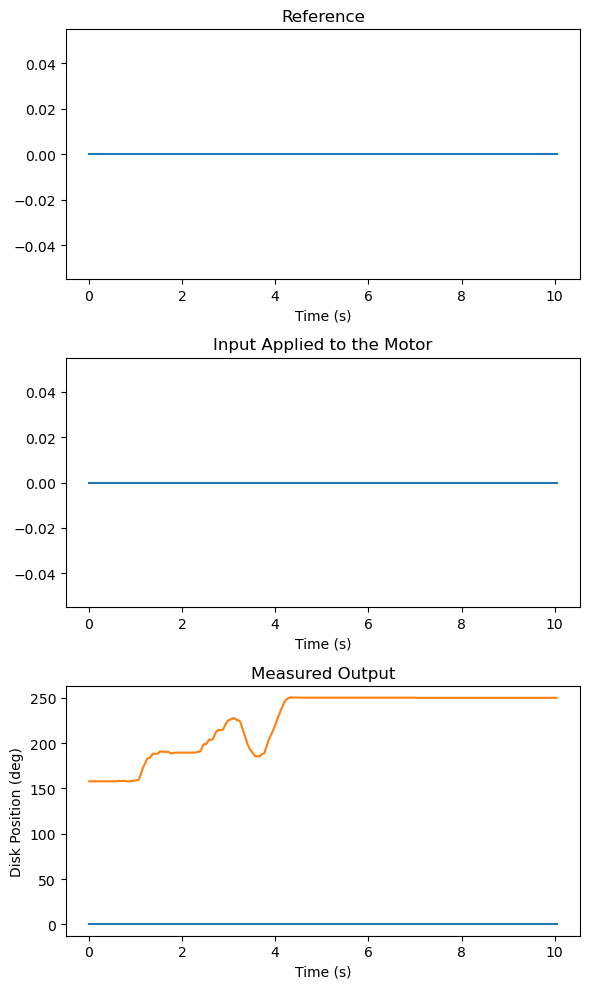

In [13]:
disk_position_measured = measured_outputs[0]*counts_per_revolution_to_rad/np.pi*180
input_to_motor = measured_outputs[1]
dt_measured = measured_outputs[2]
t_measured = np.cumsum(dt_measured)/1000


fig,ax = plt.subplots(3,1, figsize=(6,10))
ax[0].plot(t_measured,u0)
ax[0].set_title('Reference')
ax[0].set_xlabel('Time (s)')
ax[1].plot(t_measured,input_to_motor)
ax[1].set_title('Input Applied to the Motor')
ax[1].set_xlabel('Time (s)')
ax[2].plot(t_measured,u0,label='Desired Disk Position')
ax[2].plot(t_measured,disk_position_measured,label='Measured Disk Position')
ax[2].set_title('Measured Output')
ax[2].set_xlabel('Time (s)')
ax[2].set_ylabel('Disk Position (deg)')
fig.tight_layout()

# Question 1

How did the open loop system react to disturbances? Explain this behavior. Why does it react this way?

It didn't react to the disturbance because it has no feedback which measures the disturbance.

# Bang-Bang Controller

Next we will look at a so-called bang-bang controller. The main idea is that when there is a difference between the desired position (the reference) and the actual position, we apply a voltage to the motor to move it in the direction to make the difference (error) smaller. You might remember this controller from the first week of class.

The idea is:

```
If (desired position < measured position):
    move in forward direction (apply 6 V)
if (desired position > measured position):
    move in backwards direction (apply -6V)
```

Implement this algorithm on the Arduino. Comment out the open-loop code, and add your code to the section marked bang-bang controller. Note that you are essentially writing in C, so use the proper syntax. You only need to change the code between the lines 140 to 162. Please do not change the code elsewhere. Your code should only be a few lines long.

**Important**: when you write your code, $u[ii]$ should be the input applied to the motor.  

Note that to apply a voltage of 6V to the motor, the input variable in the Arduino, $u[ii]$, needs to have a magnitude of 125. Similarly, to apply a voltage of -6V, the input, $u[ii]$, should be -125.

Compile the code and make sure there are no errors using the check mark button. When it compiles, upload it to the Arduino. 

Attach a snip of your code (or rewrite it) below as part of your report. 

### Run the Experiment

Note that now the reference is no longer directly applied to the input of the motor. 

Now you will investigate the effect of disturbances on the system in **closed** loop. 

While the simulation is running, manually move the disk on the motor side (you might have to be a bit forcefull). Now there is a difference between the desired position ($0$ degrees) and the measured position. 

What is the system going to do? 

Run the following code and find out! 

Note: sometimes after flashing the Arduino, the com port is blocked for Python. You may need to restart your kernel in this case by clicking the Restart button in your Python IDE. This means you will lose all your variables, so I have copied the code you need below. Make sure to enter your com port number. 

In [30]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import serial
import ENELX41_lab_util as lu

arduino_com_port =  'COM13'# enter your com port here.

N = 1000    #data length. Our simulation will be 10 seconds long. 
            #The sampling rate of the system is 100 samples per second
t = np.linspace(0,10-10/N,N)
counts_per_revolution_to_rad = 1/2048*2*np.pi  #there are 2048 encoder pulses per revolution.

u0 = np.zeros(N)  # the initial reference we will use
u0_mag, u0_dir = lu.signal_to_mag_and_dir(u0)   # the reference needs to be split into a magnitude contained 
                                                            #in 1 byte, and a direction contained in 1 bit.
Kp = 0 # the proportional gain is not used in this part of the lab, but we need to set it to a value.

measured_outputs = lu.run_motor_and_disk_closed_loop(u0_mag,u0_dir,Kp,com_port=arduino_com_port)    # this line will initiate communication with the Arduino.
                                                                                                    # It takes a while to run because first it sends the desired 
                                                                                                    # reference to the Arduino, then it runs the experiment 
                                                                                                    # (which lasts 10s), then it sends the measured output and 
                                                                                                    # input applied to the plant back to Python via the USB 
                                                                                                    # attached to the COM port. 

Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Proportional gain of controller set to:  0
Simulation is running.
Simulation has ended.


# Plot the results

Use the following code to plot the results of your experiment. 

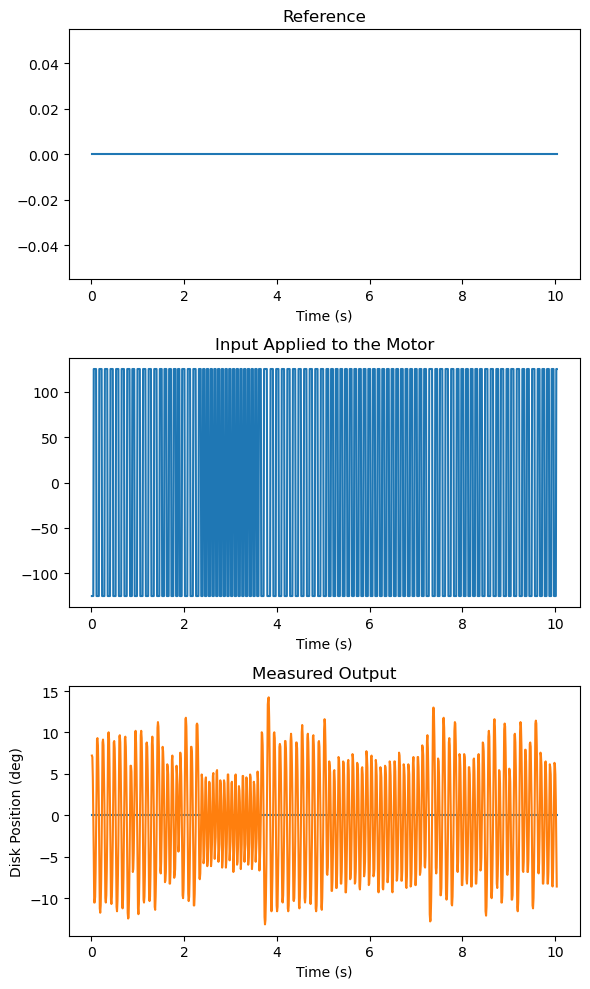

In [31]:
disk_position_measured = measured_outputs[0]*counts_per_revolution_to_rad/np.pi*180
input_to_motor = measured_outputs[1]
dt_measured = measured_outputs[2]
t_measured = np.cumsum(dt_measured)/1000


fig,ax = plt.subplots(3,1, figsize=(6,10))
ax[0].plot(t_measured,u0)
ax[0].set_title('Reference')
ax[0].set_xlabel('Time (s)')
ax[1].plot(t_measured,input_to_motor)
ax[1].set_title('Input Applied to the Motor')
ax[1].set_xlabel('Time (s)')
ax[2].plot(t_measured,u0,label='Desired Disk Position')
ax[2].plot(t_measured,disk_position_measured,label='Measured Disk Position')
ax[2].set_title('Measured Output')
ax[2].set_xlabel('Time (s)')
ax[2].set_ylabel('Disk Position (deg)')
fig.tight_layout()

# Question 2

How did the closed loop system react to disturbances? Explain this behavior. Why does it react this way? 

The closed loop system attempted to reset its position, but kept overshooting causing an oscillatory motion around the reference point which didn't stop

# Proportional Control

In this section you will implement a proportional controller. You may have noticed that the bang-bang controller never quite settled to zero. That is because it is always applying either +12V or -12V. Ideally, when we are close to the desired position, we want to apply a small voltage to nudge the motor to the right position. This is what a proportional controller does. 

It applies a voltage that is proportional to the error (the distance from the desired position). if the distance is big, then apply a big voltage, but if the distance is small, apply a small voltage. This can be expressed as the following equation:
$$
u(t) = K_p(y(t) - r(t))
$$
where 
- $u(t)$ is the input to the plant, i.e. the signal sent to the motor, 
- $y(t)$ is the position of the shaft as read by the encoder,
- $r(t)$ is the reference signal, which is the desired position of the disk.

# Question 3

Draw a block diagram of a system with this controller. Include the plant, controller reference, input and 
output in your diagram. Hint: it should look like a closed loop. 
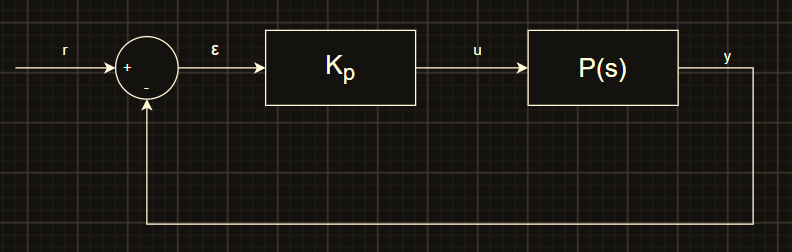

### Implement Controller on Arduino 

Implement this algorithm on the Arduino. Comment out the code for the bang-bang controller, and add your code to the section marked proportional controller. Again, note that you are essentially writing in C, so use the proper syntax. You only need to change the code between the lines 140 to 162. Please do not change the code elsewhere. Your code should only be one line. 

**Important**: when you write your code, $u[ii]$ should be the input applied to the motor.  

Compile the code and make sure there are no errors using the check mark button. When it compiles, upload it to the Arduino. 

Attach a snip of your code (or rewrite it) below as part of your report. 

### Run the Experiment

Again, you will investigate the effect of disturbances on the system in closed loop. 

While the simulation is running, manually move the disk on the motor side a little bit. Now there is a difference between the desired position ($0$ degrees) and the measured position. 

What is the system going to do? 

Run the following code and find out! 

In [27]:
# comment out one the lines below (depending on what set up you have)

# Kp = 0.05      # if you have a metal setup, set the set the proportional gain to 0.05.
Kp = 0.2       # if you have a plastic setup, set the proportional gain to 0.2 

In [91]:
# PG = 0.5
Kp = 0.5

In [94]:
# PG = 0.5
Kp = 1

In [95]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import serial
import ENELX41_lab_util as lu

arduino_com_port =  'COM13'

N = 1000    #data length. Our simulation will be 10 seconds long. 
            #The sampling rate of the system is 100 samples per second
t = np.linspace(0,10-10/N,N)
counts_per_revolution_to_rad = 1/2048*2*np.pi  #there are 2048 encoder pulses per revolution.

u0 = np.zeros(N)  # the initial reference we will use
u0_mag, u0_dir = lu.signal_to_mag_and_dir(u0)   # the reference needs to be split into a magnitude contained 
                                                            #in 1 byte, and a direction contained in 1 bit.
measured_outputs = lu.run_motor_and_disk_closed_loop(u0_mag,u0_dir,Kp,com_port=arduino_com_port)    # this line will initiate communication with the Arduino.
                                                                                                    # It takes a while to run because first it sends the desired 
                                                                                                    # reference to the Arduino, then it runs the experiment 
                                                                                                    # (which lasts 10s), then it sends the measured output and 
                                                                                                    # input applied to the plant back to Python via the USB 
                                                                                                    # attached to the COM port. 

Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Proportional gain of controller set to:  1
Simulation is running.
Simulation has ended.


# Plot the results

Use the following code to plot the results of your experiment. 

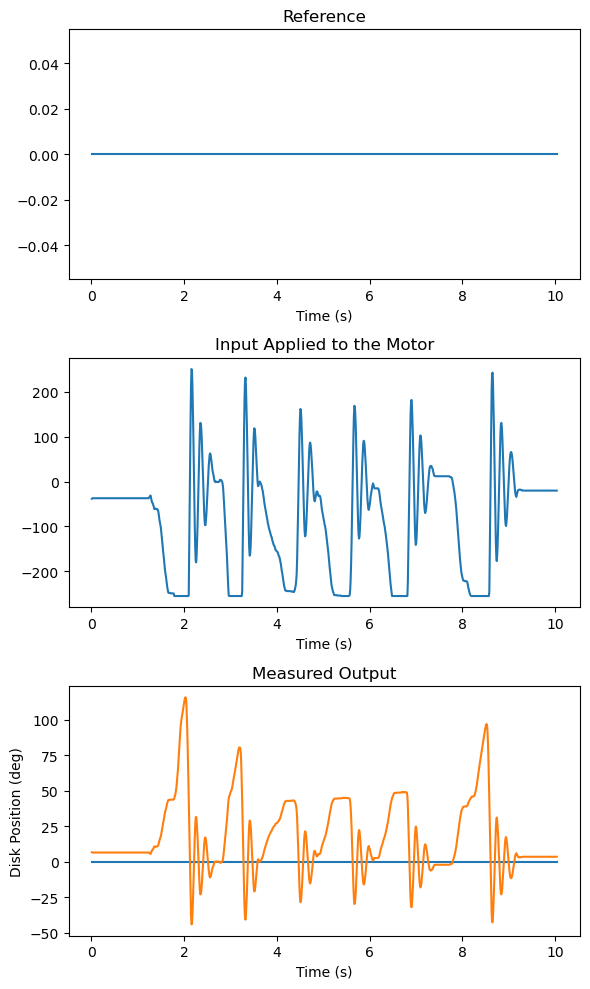

In [96]:
disk_position_measured = measured_outputs[0]*counts_per_revolution_to_rad/np.pi*180
input_to_motor = measured_outputs[1]
dt_measured = measured_outputs[2]
t_measured = np.cumsum(dt_measured)/1000


fig,ax = plt.subplots(3,1, figsize=(6,10))
ax[0].plot(t_measured,u0)
ax[0].set_title('Reference')
ax[0].set_xlabel('Time (s)')
ax[1].plot(t_measured,input_to_motor)
ax[1].set_title('Input Applied to the Motor')
ax[1].set_xlabel('Time (s)')
ax[2].plot(t_measured,u0,label='Desired Disk Position')
ax[2].plot(t_measured,disk_position_measured,label='Measured Disk Position')
ax[2].set_title('Measured Output')
ax[2].set_xlabel('Time (s)')
ax[2].set_ylabel('Disk Position (deg)')
fig.tight_layout()

# Question 4

How did the closed loop system react to disturbances? Explain this behavior. Why does it react this way? 

When the system detected a disturbance, it rotated to counteract the disturbance, slowing down as it approached the reference, with a small overshoot. This is because as the measured position approaches the reference, the gain becomes less. One problem seen was that the measured position was still slightly off from the reference, as the error was too small to have an effect.

# Investigating the effect of changing the gain of the proportional controller.

Next, slowly increase the proportional gain of the controller. Use increments of $0.1$.

For the plastic set-up try the gains: 0.2, 0.5, 1.

For the metal set-up try the gains: 0.05, 0.2, 0.5.

Again, apply a disturbance to the system by manually moving the disk closest to the motor. How did the system respond? How was is different from the system with a smaller gain?

The system with a higher gain responded stronger with more overshoot when settling.

# Question 5

Show your plots for the different gains. Provide a description of how the response of the system is different in each case. Discus how settling time, overshoot, and peak time are changing as the gain is changing. How does it feel different when moving the disk in each case?

Kp=0.2


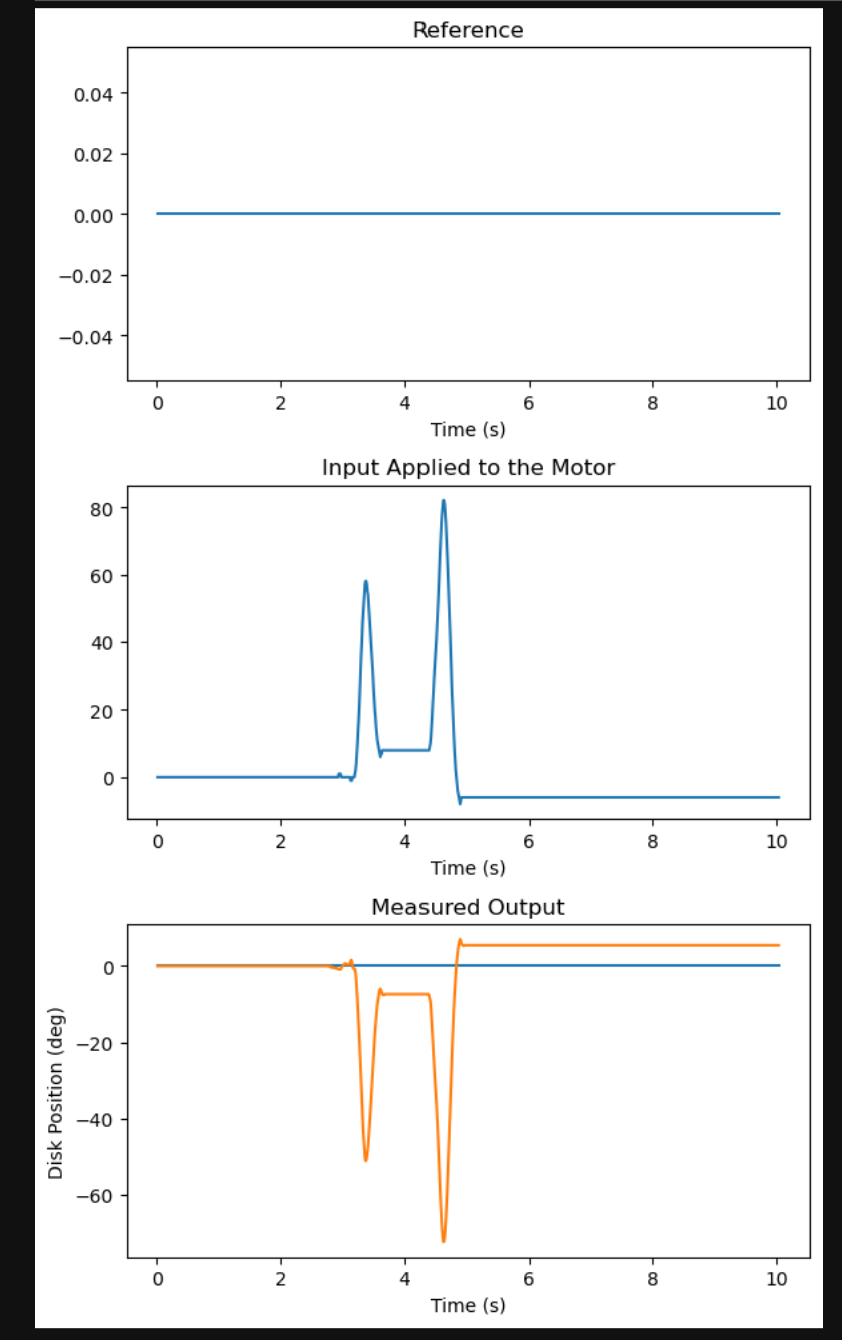

Kp = 0.5


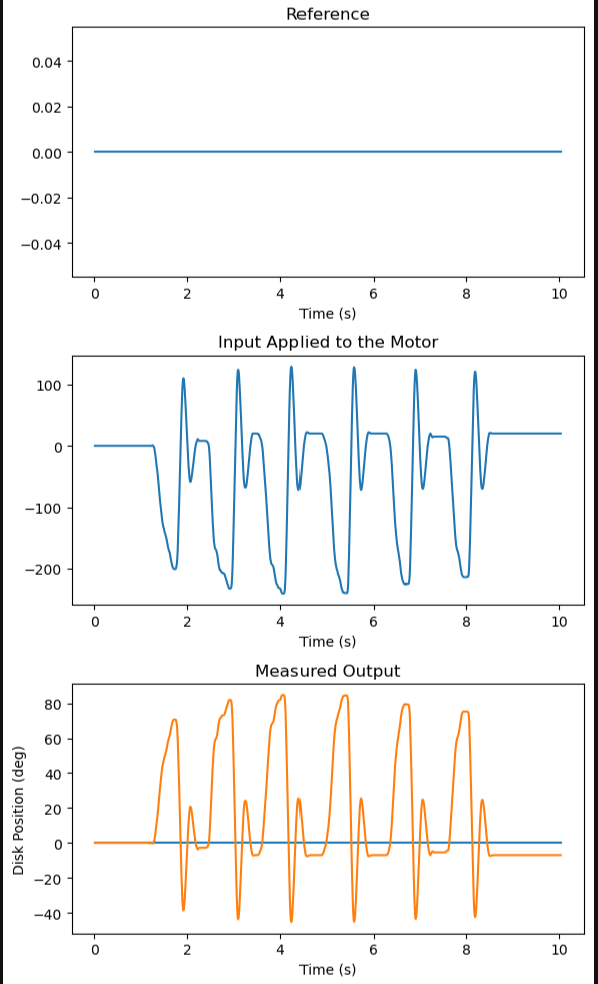

Kp = 1


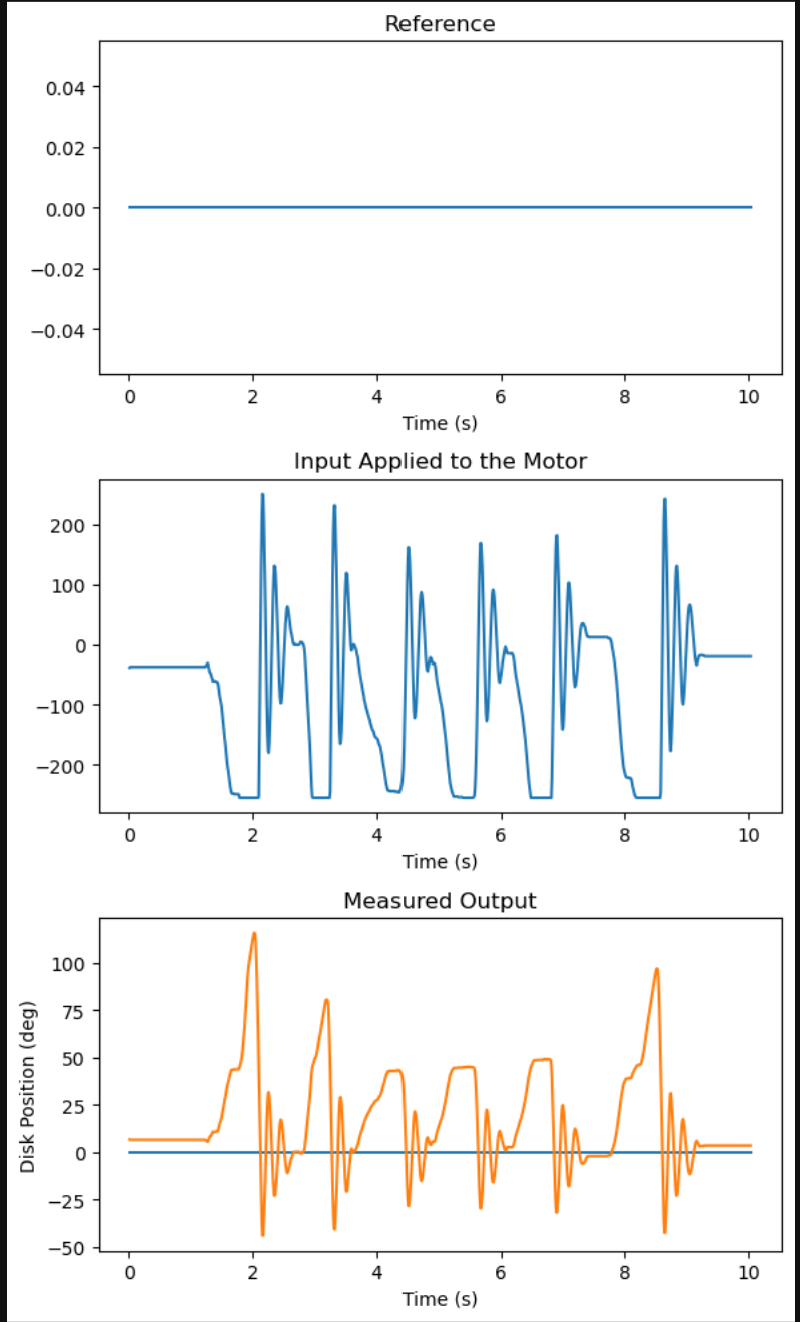

# TA check. 

Call over a TA to discus the results so far.

# Closed-Loop Step Response and Closed-Loop Poles

In this part of the lab you will study the effect of the proportional gain (i.e. $K_p$) on the step response of the system. 

A very interesting fact is that you cannot change the poles of the open loop system (unless you physically alter the design). However, by changing the gain of the controller, you can change the closed loop behavior of the system! That is amazing! Now the question is: what behavior do you want the system to have, and what gain corresponds to that behavior. This is the topic of this course! 

Note: when I say behavior, I mean peak time, percent overshoot, and settling time of the system.

In the following part of the lab you will start to see how changing the gain changes the closed loop behavior. 

The way that the controller is implemented on the Arduino we have that the voltage applied to the motor is equal to:
$$
u(t) = K_p( r(t) - \theta_d(t)),
$$
where $\theta_d$ is the output of the encoder (i.e. the position of the disk attached to the encoder).

In the pre-lab you derived an expression for the transfer function from the reference $r(t)$ to the measured output, $\theta_d(t)$? Look up this expression now. Note that the controller gain, $K_p$ shows up in the denominator of the transfer function. This means that by changing the gain, you are changing the (closed-loop) poles of the system. Which in turn means that the behavior of the system will change. 

In the following steps you will set the reference signal to be a sequence of steps. The output will then be a series of step responses (of the closed loop system). In the following steps you will observe the change in system behavior by plotting the step response of the closed loop system for different values of $K_p$.

# The Input

In the following cell we construct a series of step changes of plus or minus $90$ degrees. This is our desired position for the disk (we want the disk to instantly move 180 degrees forward, then after 2 seconds move back to the original position, then after another 2 seconds move forward 90 degrees, etc.). 

In [44]:
u_step = 90*np.ones(1000)           # a step input of 90 degrees
u_step[200:400] = np.zeros(200)       # the first second is 0, then after 1 s the step is applied.
u_step[600:800] = np.zeros(200)
u_step_mag, u_step_dir = lu.signal_to_mag_and_dir(u_step)   # the reference needs to be split into a magnitude contained 
                                                            #in 1 byte, and a direction contained in 1 bit.

Text(0, 0.5, 'Position (degrees)')

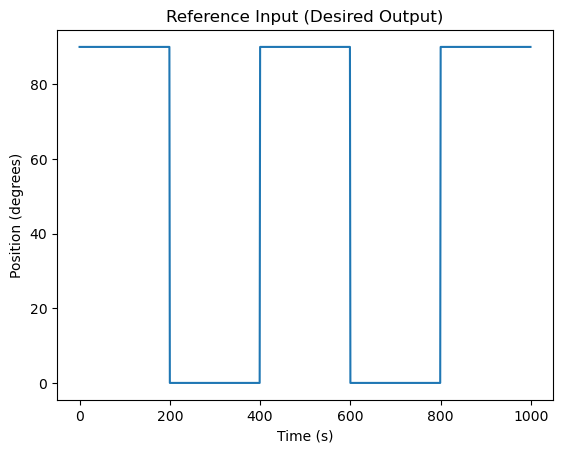

In [45]:
fig,ax = plt.subplots(1)
ax.plot(u_step)
ax.set_title('Reference Input (Desired Output)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Position (degrees)')


# Set the Proportional Gain

METAL: You will start with small gain of $0.05$. 

PLASTIC: Start with a gain of $0.2$.

In [46]:
Kp = 0.2   # Kp is the proportional gain of the controller. Intially we will set the proportional gain to either 0.05 or 0.2.

# The Experiment

The following code will run the experiment. Again, the experiment will only last 10s. You should see the motor move 90 degrees back and forth. 

Note: if the disks don't move, but the motor makes a sound, then the gain is not quite high enough to overcome the friction in the system. Slightly increase the gain in increments of 0.05 until the motor starts to move. 

In [47]:
measured_outputs = lu.run_motor_and_disk_closed_loop(u_step_mag,u_step_dir,Kp,com_port=arduino_com_port)

Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Proportional gain of controller set to:  0.2
Simulation is running.
Simulation has ended.


# Plot the measured data

Text(0, 0.5, 'Disk Position (deg)')

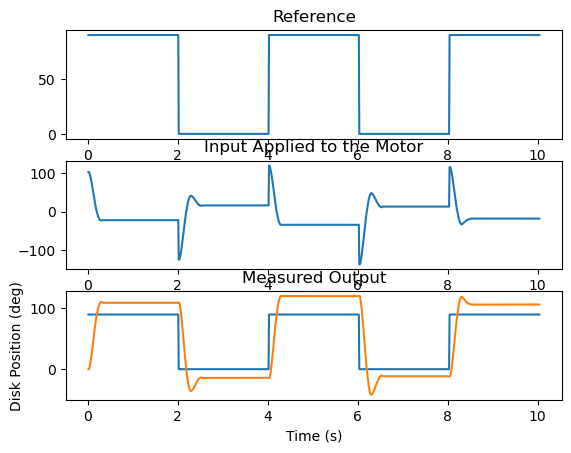

In [49]:
disk_position_measured = measured_outputs[0]*counts_per_revolution_to_rad/np.pi*180
input_to_motor = measured_outputs[1]
dt_measured = measured_outputs[2]
t_measured = np.cumsum(dt_measured)/1000


fig,ax = plt.subplots(3,1)
ax[0].plot(t_measured,u_step)
ax[0].set_title('Reference')
ax[0].set_xlabel('Time (s)')
ax[1].plot(t_measured,input_to_motor)
ax[1].set_title('Input Applied to the Motor')
ax[1].set_xlabel('Time (s)')
ax[2].plot(t_measured,u_step,label='Desired Disk Position')
ax[2].plot(t_measured,disk_position_measured,label='Measured Disk Position')
ax[2].set_title('Measured Output')
ax[2].set_xlabel('Time (s)')
ax[2].set_ylabel('Disk Position (deg)')

# Estimate the final value, percent overshoot and peak time of the step response. 

The following code takes the 5 step responses and plots them on top of each other. 

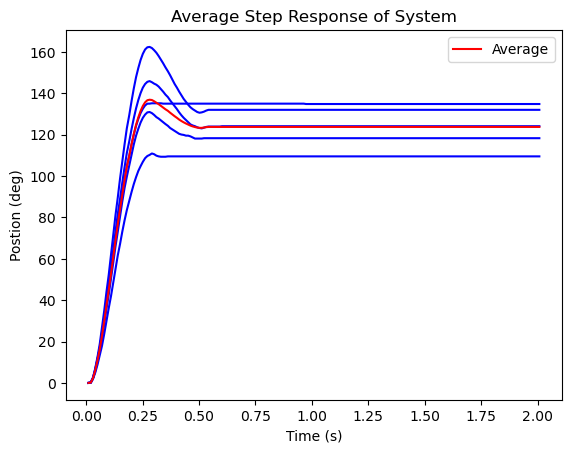

In [51]:
# each step response is 200 samples
Ns = 200

# split the array into 5 arrays of length 200
measured_steps = np.reshape(disk_position_measured,(5,Ns)).T.copy()
for jj in range(5):
    measured_steps[:,jj] -= measured_steps[0,jj]  #subtract the starting point so that they all start at 0

# flip the 2nd and 4th step responses (they are in the reverse direction)
measured_steps[:,1] *= -1
measured_steps[:,3] *= -1

# calculate the average step response
ave_measured_steps = np.mean(measured_steps,axis=1)

# plot the results
fig,ax = plt.subplots(1)
ax.plot(t_measured[0:Ns],measured_steps,'b')
ax.plot(t_measured[0:Ns],ave_measured_steps,'r', label='Average')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Postion (deg)')
ax.set_title('Average Step Response of System')
ax.legend()

We will use the step response to estimate the (dominant) poles of the system. If your response does not have any overshoot, increase the gain by 0.05 until it has some overshoot. What does it say about your system if there is no overshoot?

Write a function to estimate the 2\% settling time of the average step response.


In [75]:
# write your code here
i = Ns - 1
while(ave_measured_steps[i] > 0.98 * ave_measured_steps[Ns - 1] and ave_measured_steps[i] < 1.02 * ave_measured_steps[Ns - 1]):
    i -= 1
settling_time = t_measured[i + 1]
print(t_measured[i + 1])

0.432


Write a function to estimate the peak time of the average step response.

In [63]:
# write your code here
index = np.argmax(ave_measured_steps)
peak_time = t_measured[index]
print(t_measured[index])

0.281


From the peak time and the settling time you can estimate the pole locations of a second order approximation to the system (essentially the dominant poles). Calculate these pole locations here. 

In [7]:
# write your code here
#used values from previous
settling_time = 0.432
peak_time = 0.281
alpha = 4/ settling_time
beta = np.pi/peak_time

print(f"{-alpha} +/- {beta}j")

-9.25925925925926 +/- 11.180045030568659j


# Increasing Gain

Next, slowly increase the proportional gain of the controller. Use increments of $0.05$.

For the *plastic* set up start at 0.5 and increase the gain up to 2.5

For the *metal* set up start at 0.05 and increase the gain up to 2. 

Estimate the settling time and peak time each time that you increase the gain. Is the settling time increasing or decreasing? What does this tell you about the location of the poles of the closed loop system? For each value of $K_p$, estimate the pole locations and:
- save the estimated pole locations in an array,
- save the final value of the step response in an array.

Remember the expression for the closed loop transfer function that you derived. Note that changing the gain $K_p$ will change the closed loop pole locations (which means that the closed loop response changes). 

In [83]:
# write your code here
settling_array = np.array([])
peak_array = np.array([])
final_value_array = np.array([])

for kp in range(50,255,5):
    kp = kp/100
    measured_outputs = lu.run_motor_and_disk_closed_loop(u_step_mag,u_step_dir,kp,com_port=arduino_com_port)

    disk_position_measured = measured_outputs[0]*counts_per_revolution_to_rad/np.pi*180
    input_to_motor = measured_outputs[1]
    dt_measured = measured_outputs[2]
    t_measured = np.cumsum(dt_measured)/1000

    # each step response is 200 samples
    Ns = 200
    
    # split the array into 5 arrays of length 200
    measured_steps = np.reshape(disk_position_measured,(5,Ns)).T.copy()
    for jj in range(5):
        measured_steps[:,jj] -= measured_steps[0,jj]  #subtract the starting point so that they all start at 0
    
    # flip the 2nd and 4th step responses (they are in the reverse direction)
    measured_steps[:,1] *= -1
    measured_steps[:,3] *= -1
    
    # calculate the average step response
    ave_measured_steps = np.mean(measured_steps,axis=1)


    i = Ns - 1
    while(ave_measured_steps[i] > 0.98 * ave_measured_steps[Ns - 1] and ave_measured_steps[i] < 1.02 * ave_measured_steps[Ns - 1]):
        i -= 1
    
    settling_time = t_measured[i + 1] #<-----------------
    settling_array = np.append(settling_array, settling_time)
    
    index = np.argmax(ave_measured_steps)
    

    peak_time = t_measured[index]  #<-----------------
    peak_array = np.append(peak_array, peak_time)


    final_value_array = np.append(final_value_array, ave_measured_steps[Ns - 1])


np.savetxt('settling_array.csv', settling_array, delimiter=',' )
np.savetxt('peak_array.csv', peak_array, delimiter=',' )
np.savetxt('final_value_array.csv', final_value_array, delimiter=',' )

Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Proportional gain of controller set to:  0.5
Simulation is running.
Simulation has ended.
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Proportional gain of controller set to:  0.55
Simulation is running.
Simulation has ended.
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Proportional gain of controller set to:  0.6
Simulation is running.
Simulation has ended.
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Proportional gain of controller set to:  0.65
Simulation is running.
Simulation has ended.
Arduino completed setup.
Computer and Arduino communicating and ready.
Sending data to Arduino.
Proportional gain of controller set to:  0.7
Simulation is running.
Simulation has ended.
Arduino completed setup.
Computer and Arduino communicating and read

# S-Plane plot

Make an s-plane plot of the estimated pole locations for each value of $K_p$. In other words, plot all the estimated poles on one plot. You are plotting the closed-loop poles for different values of $K_p$. 

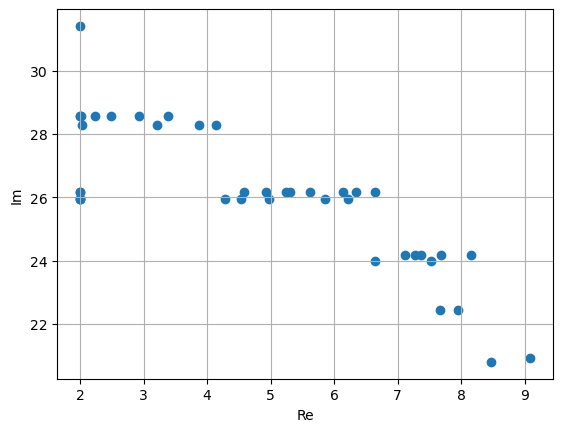

In [ ]:
# write your code here
alpha = 4/settling_array
beta = np.pi/peak_array

plt.scatter(-alpha, beta)
plt.scatter(-alpha, -beta)
plt.xlabel('Re')
plt.ylabel('Im')
plt.grid()
plt.show()

# Questions

What did you notice about the stability of the system for large values of $K_p$? How does unstability manifest in the real world? (I am assuming the system did not actually blow up!).

What direction in the s-plane are the poles moving? 

What does this say about the stability of the system as a function of $K_p$?

# Final Value

Plot the final value of the step response vs. the proportional gain $K_p$.

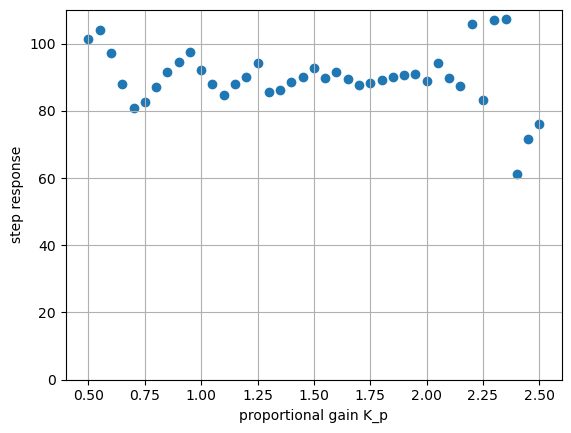

In [98]:
prop_gain = np.array(range(50,255,5),dtype=float)
prop_gain /= 100
plt.scatter(prop_gain, final_value_array)
plt.xlabel('proportional gain K_p')
plt.ylabel('step response')
plt.ylim(0,110)
plt.grid()
plt.show()

# Questions

What do you notice in the plot? We will prove this behavior in the lectures. It is a feature of proportional control, that for small gains the final value is not exactly equal to the desired final value, but as you increase the gain, you get closer to the desired final position. 

# End of Lab

Discuss the results of this excersize with one of the lab supervisors.